In [1]:
import torch
import torch.nn as nn
from spd_learn.functional import covariance
import pymanopt
import numpy as np
from src.data.dataset_config import DATASET_CONFIG
from src.Visualization.topomap import plot_topomap, plot_pannel
from src.Permutation.FeaturePermutationEEG import FeaturePermutationEEG, DeepFeaturePermutationEEG
from pyriemann.classification import MDM, TSClassifier
from pyriemann.utils.mean import mean_riemann
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from moabb.paradigms import FilterBankMotorImagery
from moabb.datasets import BNCI2014_001, Dreyer2023C, Beetl2021_A
from sklearn.model_selection import train_test_split


from pyriemann.tangentspace import TangentSpace
from functools import partial
import math
import matplotlib.pyplot as plt

In [2]:
import sys
print(sys.executable)

/home/omille/miniconda3/envs/StageM2/bin/python


In [3]:
np.random.seed(3)

In [4]:
DATA_DIR = '/home/omille/Documents/Stage/Rendu/'

# Permutation Feature Importance

## EEG version

### Tabular Data

In [5]:
X_toy = np.random.rand(10,22,1000)
y_toy = np.array([0,0,0,0,0,1,1,1,1,1])

In [6]:
from sklearn.pipeline import Pipeline
pipeline_mdm = Pipeline([
        ('cov', Covariances(),),
        ('clf', MDM())]
    )

In [7]:
#Minimal use : only X and y, no multiple datasets / subjects
perm = FeaturePermutationEEG()

# We do n_perm permutations on n_splits splits
#Ici, on fourni une pipeline de transformation des données en matrices SPD + de classificaiton et perm.fit va donc à la fois entraîner le modèle sur n_splits splits 
#et en même temps calculer ses valeurs d'importance
perm.fit(X_toy, y_toy, n_splits = 5, n_perm = 5, pipeline = pipeline_mdm)

#Une fois la permutation calculée, on peut afficher les importances, de taille (n_iter, n_features) avec importance_
#On peut aussi consulter les accuracy (une par itération)
print(perm.importance_)
print(perm.accuracy_)

[[ 0.1  0.   0.   0.   0.   0.   0.   0.   0.1  0.1  0.1  0.2  0.   0.
   0.   0.   0.   0.   0.   0.   0.   0. ]
 [-0.6 -0.2 -0.3 -0.2 -0.2  0.  -0.5 -0.4  0.  -0.2 -0.3 -0.5 -0.1 -0.1
  -0.4 -0.7 -0.1  0.  -0.4  0.  -0.2  0. ]
 [ 0.1  0.4 -0.4 -0.1 -0.1  0.1 -0.2  0.1  0.4  0.  -0.2  0.  -0.2  0.1
  -0.4  0.1  0.4  0.5  0.  -0.4 -0.4 -0.1]
 [-0.1  0.  -0.1  0.  -0.2  0.  -0.2  0.   0.   0.   0.  -0.3 -0.2  0.
   0.   0.   0.  -0.2  0.  -0.3  0.  -0.1]
 [ 0.   0.  -0.1  0.  -0.2  0.  -0.4 -0.1  0.   0.   0.  -0.5 -0.1 -0.1
   0.   0.   0.  -0.2  0.  -0.2  0.   0. ]]
[1.  0.  0.5 0.  0. ]


In [8]:
#Si on a une pipeline déjà entraînée, on le passe avec le paramètre pipeline_pre_trained et on ne fournit que les données sur lesquelles ont veut réaliser la PFI
#n_iter n'a plus de sens car on ne réalise pas de splits sur les données puisqu'on ne réalise pas d'entraînement
perm_trained = FeaturePermutationEEG()

X_train_toy, X_test_toy, y_train_toy, y_test_toy = train_test_split(
            X_toy, y_toy, stratify=y_toy, random_state=1, test_size=0.2
        )

pipeline_pre_trained = Pipeline([
        ('cov', Covariances(),),
        ('clf', MDM())]
    )
pipeline_pre_trained.fit(X_train_toy,y_train_toy)


perm_trained.fit(X_test_toy, y_test_toy, n_perm = 5, pipeline_pre_trained = pipeline_pre_trained)
print(perm_trained.importance_)
print(perm_trained.accuracy_)

[[-0.5  0.  -0.4 -0.3 -0.2  0.  -0.7 -0.4 -0.4  0.  -0.5 -0.4 -0.2 -0.3
  -0.3 -0.5 -0.3 -0.2 -0.3  0.  -0.2 -0.1]]
[0.]


### Moabb data

In [9]:
from src.data.moabb_adapter import load_from_moabb
from src.Permutation.multi_subjects import run_multi_subjects_eeg

In [10]:
#data is a dict where each subject is associated to its (X,y) tuple 
data_eeg, sensors = load_from_moabb("BNCI2014_001")
print(data_eeg.keys())

dict_keys(['Subject 1', 'Subject 2', 'Subject 3', 'Subject 4', 'Subject 5', 'Subject 6', 'Subject 7', 'Subject 8', 'Subject 9'])


If we want a permutation for multiple subjects, we call run_multi_subjects. It takes a dict of shape {"subject_name" : (X,y) ...}
It returns a dict with the subject names then importance of size (n_splits, n_channels) and accuracy of size (n_splits) for each subject

In [11]:
results_eeg = run_multi_subjects_eeg(data_eeg, n_splits=2, n_perm=10, pipeline = pipeline_mdm, n_jobs = -1)

Calculating importance for Subject 1...
Calculating importance for Subject 2...
Calculating importance for Subject 3...
Calculating importance for Subject 4...
Calculating importance for Subject 5...
Calculating importance for Subject 6...
Calculating importance for Subject 7...
Calculating importance for Subject 8...
Calculating importance for Subject 9...


Example of how to access the importance of subject 1 : 

In [13]:
importances_subject_1 = results_eeg['Subject 1']["importance"]
print(importances_subject_1)

[[-1.03448276e-02 -4.65517241e-02 -3.27586207e-02 -1.72413793e-02
   3.44827586e-02  0.00000000e+00  0.00000000e+00  2.75862069e-01
   3.44827586e-02 -1.72413793e-02  1.89655172e-01  1.37931034e-01
   5.17241379e-02  2.75862069e-02  4.48275862e-02  0.00000000e+00
   0.00000000e+00  1.72413793e-03  2.56896552e-01 -2.93103448e-02
  -1.55172414e-02 -8.62068966e-03]
 [-1.11022302e-16 -2.41379310e-02  6.89655172e-03 -1.11022302e-16
   1.03448276e-01  3.44827586e-02  4.82758621e-02  3.10344828e-01
   2.67241379e-01  1.89655172e-02  1.72413793e-01  1.55172414e-01
   1.20689655e-01  1.18965517e-01  2.81034483e-01 -1.11022302e-16
   5.68965517e-02  8.62068966e-02  2.58620690e-01 -1.20689655e-02
  -1.11022302e-16 -1.11022302e-16]]


We can visualize these importances thanks to plot_topomap. 

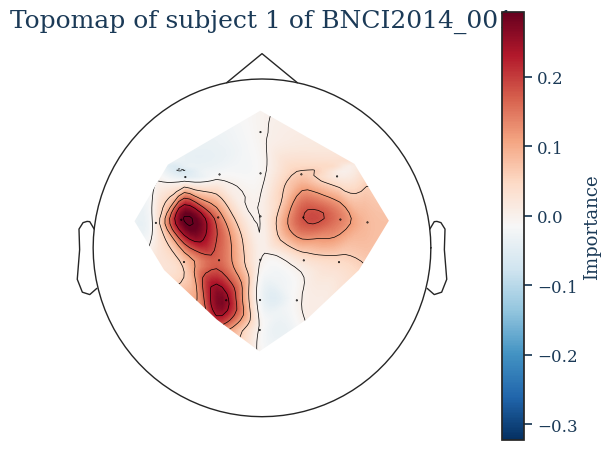

In [14]:
#takes in input an array of size (n_features), the sensors, the title and other by default parameters
#cbar_type is Shapley by default and defined the colors and labels of the color bar
#savefile_name is None by default
plot_topomap(np.mean(importances_subject_1, axis = 0), sensors, "Topomap of subject 1 of BNCI2014_001", cbar_type = 'Permutation', savefile_name = DATA_DIR+'topomap_subject_1.pdf')

If we group the results together, we can plot the topomaps for all subjects, along with their accuracies

In [15]:
#Plotting all subjects
importances_all_subjects = np.array([np.mean(results_eeg[f'Subject {i}']["importance"], axis = 0) for i in range(1,10)])
scores_all_subjects = np.array([np.mean(results_eeg[f'Subject {i}']["accuracy"], axis = 0) for i in range(1,10)])

In [16]:
print(importances_all_subjects.shape)
print(scores_all_subjects.shape)

(9, 22)
(9,)


In [17]:
print(scores_all_subjects)

[0.8362069  0.49137931 0.88793103 0.68965517 0.54310345 0.69827586
 0.68965517 0.94827586 0.77586207]


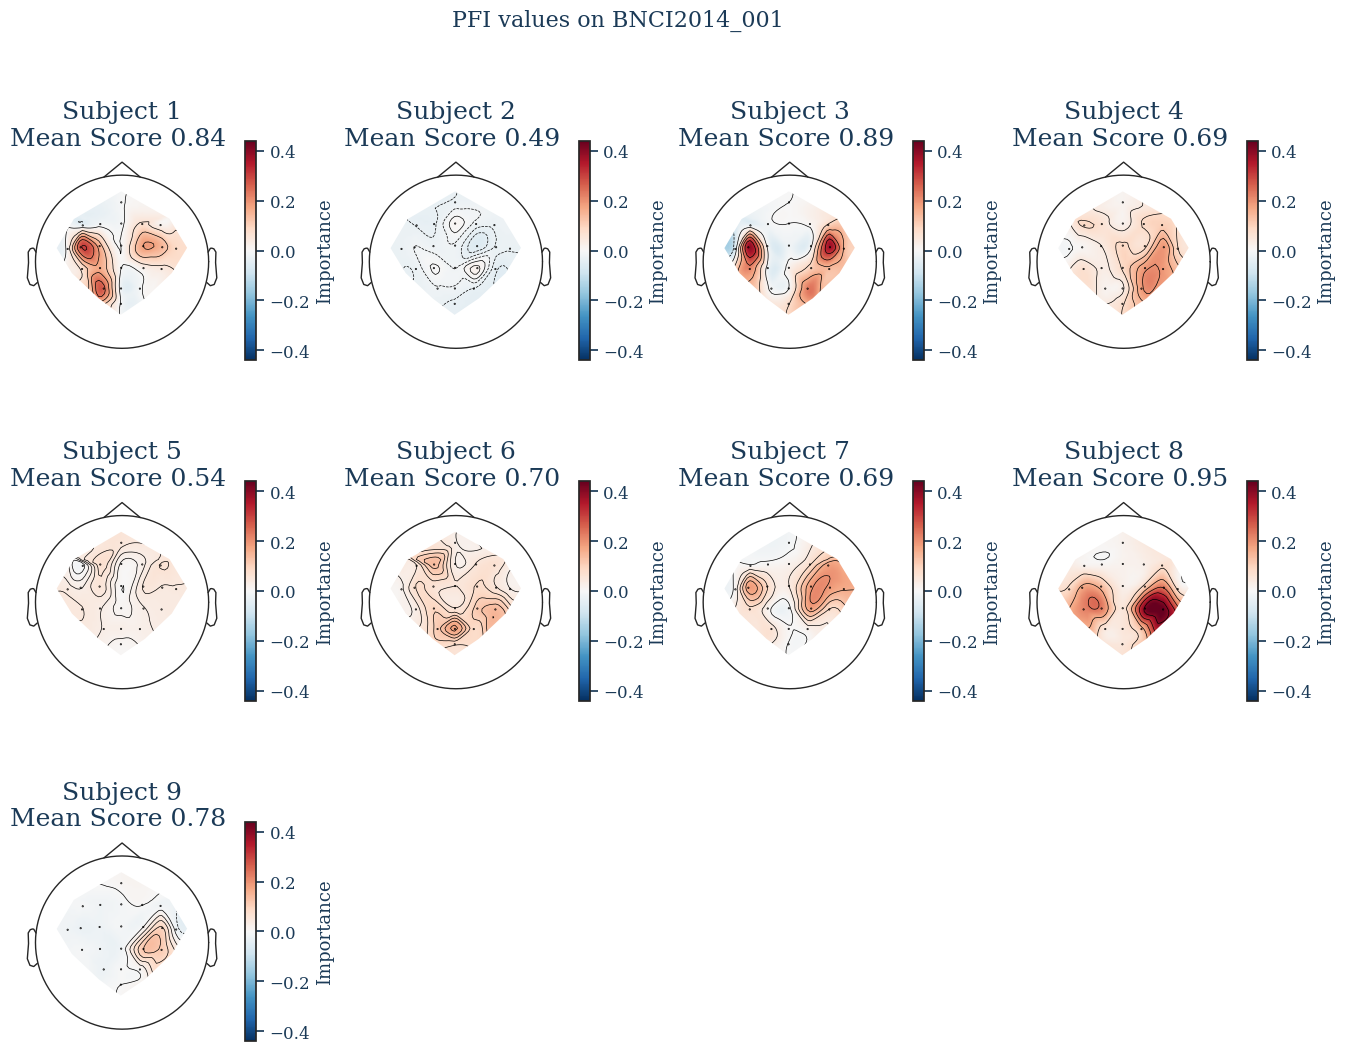

In [18]:
#plot_pannel takes importances for all subjects, subjects names, sensors names, accuracy scores as main parameters
plot_pannel(importances_all_subjects, list(data_eeg.keys()), sensors, scores_all_subjects, suptitle = "PFI values on BNCI2014_001", cbar_type = 'Permutation', savefile_path = DATA_DIR+'topomap_all_subjects.pdf')

Using a deep model: an example with SPDNet. Either you process a single dataset and use `DeepFeaturePermutationEEG`, or you have a dictionary mapping each subject to a dataset and use `run_multi_subjects_deep`. As with the non-deep version, you can either pass a pre-trained model via `model_trained`—in which case the function expects input tensors—or simply provide the model configuration (`model_config`) and type (`model_type`), in which case the function handles the conversion automatically and expects NumPy data. Below, I demonstrate the use of this method with the SPDNet used in the paper.

In [19]:
from spd_learn.modules import BiMap, CovLayer, LogEig, ReEig, SPDBatchNormMeanVar

class SPDNetBatchNorm(nn.Module):

    def __init__(
        self,
        input_type="raw",
        cov_method=covariance,
        subspacedim=None,
        threshold=1e-4,
        upper=True,
        n_chans=None,
        n_outputs=None,
        bn = None
    ):
        super().__init__()

        if subspacedim is None:
            warn(
                "subspacedim is None, using the default value of "
                "the number of channels",
                UserWarning,
            )
            subspacedim = n_chans

        if input_type == "raw":
            self.cov = CovLayer(method=cov_method)
        elif input_type == "cov":
            self.cov = nn.Identity()

        self.bimap = BiMap(n_chans, subspacedim)
        self.bn = bn
        self.reeig = ReEig(threshold)
        self.logeig = LogEig(upper=upper)
        self.len_last_layer = (
            subspacedim * (subspacedim + 1) // 2 if upper else subspacedim**2
        )
        self.classifier = nn.Linear(self.len_last_layer, n_outputs)

    def forward(self, X: torch.Tensor) -> torch.Tensor:

        X = self.cov(X)
        X = self.bimap(X)
        if self.bn is not None:
            X = self.bn(X)
        X = self.reeig(X)
        X = self.logeig(X)
        X = self.classifier(X)

        return X


In [20]:
deep_perm = DeepFeaturePermutationEEG()

In [22]:
from src.Permutation.multi_subjects import run_multi_subjects_deep_eeg

model_config = {
    "n_chans": data_eeg["Subject 1"][0].shape[1],
    "n_outputs": 2,
    "subspacedim": 16, 
    "bn" : None
}

results_eeg_deep = run_multi_subjects_deep_eeg(data_eeg, n_splits=10,n_perm=10, model_config=model_config, model_type = SPDNetBatchNorm, n_jobs = 1)

Calculating importance for Subject 1...


/home/omille/miniconda3/envs/StageM2/lib/python3.12/site-packages/torch/autograd/graph.py:882: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 10/200 - Loss: 0.6903 - Test Acc: 0.6379
Epoch 20/200 - Loss: 0.6696 - Test Acc: 0.6897
Epoch 30/200 - Loss: 0.6481 - Test Acc: 0.7414
Epoch 40/200 - Loss: 0.6258 - Test Acc: 0.8966
Epoch 50/200 - Loss: 0.6043 - Test Acc: 0.8621
Epoch 60/200 - Loss: 0.5838 - Test Acc: 0.8966
Epoch 70/200 - Loss: 0.5643 - Test Acc: 0.8966
Epoch 80/200 - Loss: 0.5457 - Test Acc: 0.8966
Epoch 90/200 - Loss: 0.5281 - Test Acc: 0.8966
Epoch 100/200 - Loss: 0.5112 - Test Acc: 0.8966
Epoch 110/200 - Loss: 0.4950 - Test Acc: 0.8966
Epoch 120/200 - Loss: 0.4795 - Test Acc: 0.8966
Epoch 130/200 - Loss: 0.4648 - Test Acc: 0.8966
Epoch 140/200 - Loss: 0.4509 - Test Acc: 0.8966
Epoch 150/200 - Loss: 0.4378 - Test Acc: 0.8966
Epoch 160/200 - Loss: 0.4255 - Test Acc: 0.8966
Epoch 170/200 - Loss: 0.4138 - Test Acc: 0.8966
Epoch 180/200 - Loss: 0.4028 - Test Acc: 0.8793
Epoch 190/200 - Loss: 0.3923 - Test Acc: 0.8793
Epoch 200/200 - Loss: 0.3824 - Test Acc: 0.8793
Epoch 10/200 - Loss: 0.6630 - Test Acc: 0.7241
Ep

Results_dic has the same shape has the non deep version and we can visualize topomaps in the same way

In [ ]:
importances_subject_1_deep = results_eeg_deep["subject_1"]["importance"]

In [ ]:
plot_topomap(np.mean(importances_subject_1_deep, axis = 0), sensors, "Topomap of subject 1 of BNCI2014_001", cbar_type = 'Permutation', savefile_name = DATA_DIR+'topomap_subject_1_deep.pdf')

In [24]:
#Plotting all subjects
importances_all_subjects = np.array([np.mean(results_eeg_deep[f'Subject {i}']["importance"], axis = 0) for i in range(1,10)])
scores_all_subjects = np.array([np.mean(results_eeg_deep[f'Subject {i}']["accuracy"], axis = 0) for i in range(1,10)])

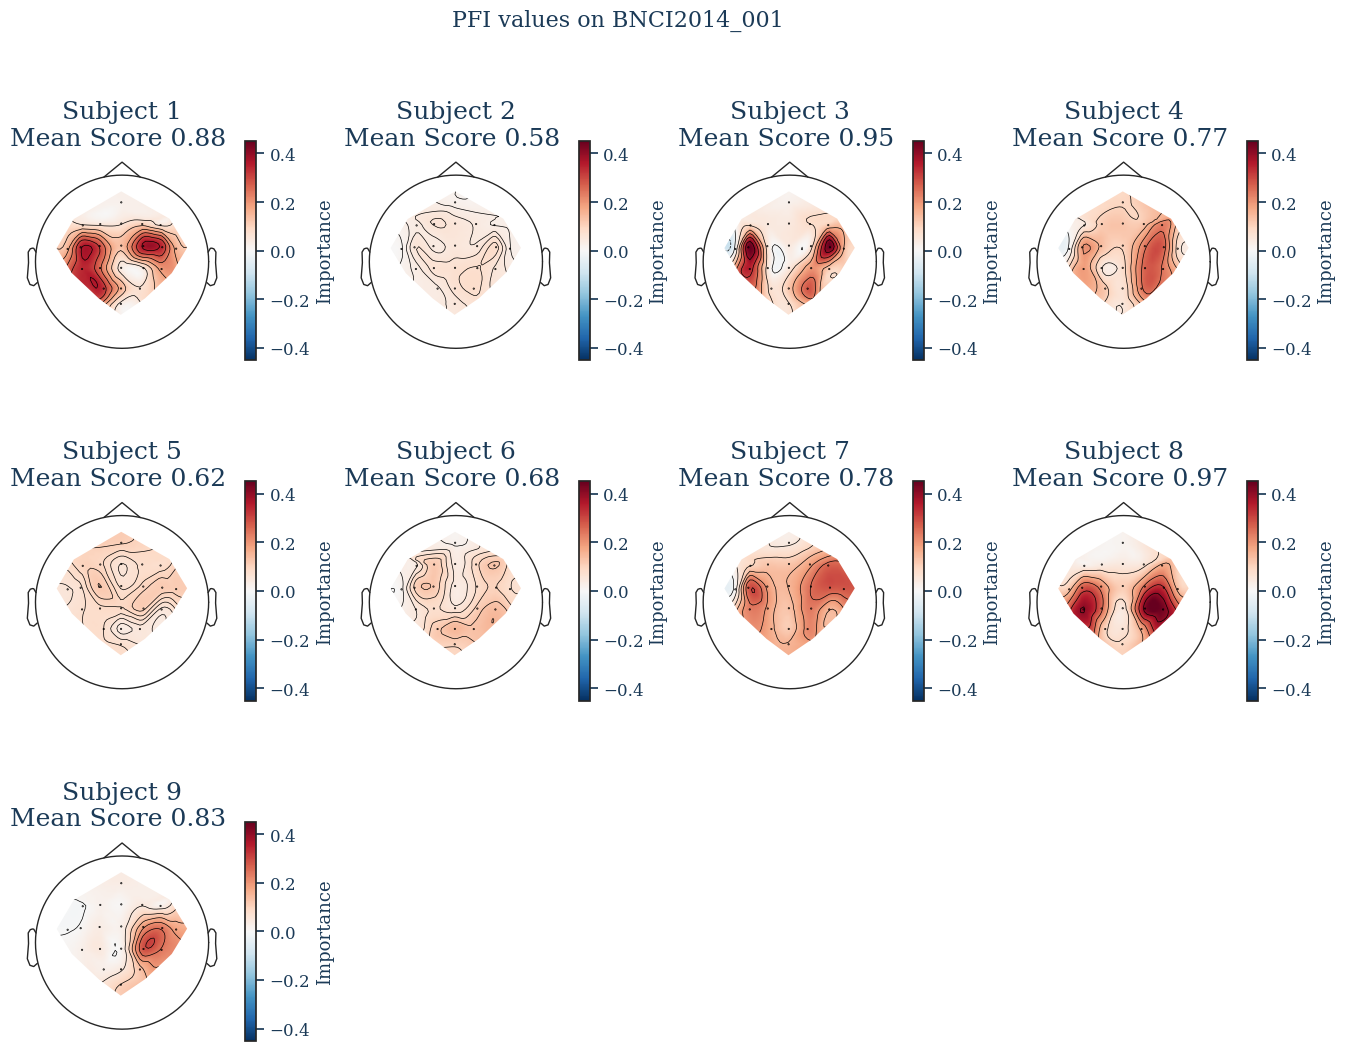

In [25]:
#plot_pannel takes importances for all subjects, subjects names, sensors names, accuracy scores as main parameters
plot_pannel(importances_all_subjects, list(data_eeg.keys()), sensors, scores_all_subjects, suptitle = "PFI values on BNCI2014_001", cbar_type = 'Permutation', savefile_path = DATA_DIR+'topomap_all_subjects_deep.pdf')

To reproduce the topomaps for high performing subjects we can use split_subjects_by_score, that takes a results_dic and returns a list of names of high performing and low performing subjects. By default the threshold to be considered a high accuracy subjects is set at 0.75 but it can be passed as a parameter. Then, stack_subjects_by_field groups all subjects' accuracies or importances (depending on the field chosen) whose names are in the array passed in subject_names in a single array. If there were multiple splits, this function also fuses the different splits.

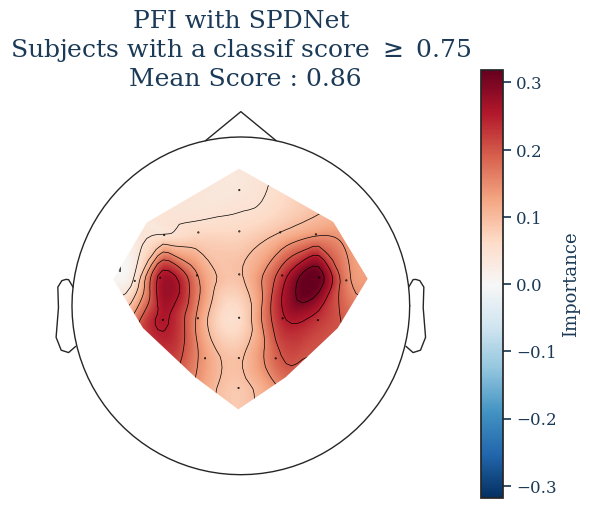

In [26]:
from src.data.utils import split_subjects_by_score, stack_subjects_by_field
high, low = split_subjects_by_score(results_eeg_deep)
importance_HP_subjects = stack_subjects_by_field(results_eeg_deep, high, field = "importance")
accuracy_HP_subjects = stack_subjects_by_field(results_eeg_deep, subject_names = high, field = "accuracy")

SCORE_THRESHOLD = 0.75

v_max = np.max(np.abs(np.mean(importance_HP_subjects,axis=0)))
v_min = -v_max

plot_topomap(np.mean(importance_HP_subjects,axis=0),sensors,
            title = f"PFI with SPDNet\nSubjects with a classif score $\\geq$ {SCORE_THRESHOLD}\n Mean Score : {np.mean(accuracy_HP_subjects):.2f}",
            vlim=(v_min,v_max),
            savefile_name='./topomap_HP_subjects.pdf',
            cbar_type = "Permutation")


## SPD version

### Tabular data

In [ ]:
from src.Permutation.FeaturePermutationSPD import FeaturePermutationSPD, DeepFeaturePermutationSPD

In [ ]:
covs = Covariances()
Covs_matrices = covs.fit_transform(X_toy)
perm_spd = FeaturePermutationSPD()
perm_spd.fit(Covs_matrices, y_toy)

In [ ]:
print(perm_spd.importance_)

### Moabb data

To extract covariances from the moabb data, we use load_from_moabb with the parameter covs set to True

In [ ]:
data_spd, sensors = load_from_moabb("BNCI2014_001", covs=True)

In [ ]:
print(data_spd["subject_1"][0].shape)

run_multi_subjects_spd allows us to compute permutation feature importance on spd matrices for multiple subjects at once. It works similarly to run_multi_subjects_eeg

In [ ]:
from src.Permutation.multi_subjects import run_multi_subjects_spd
results_spd = run_multi_subjects_spd(data_spd, n_splits=10, classifier = MDM)

In [ ]:
importances_subject_1 = results_spd['subject_1']["importance"]
print(importances_subject_1)

Plotting the results does not change between SPD and EEG methods

In [ ]:
plot_topomap(np.mean(importances_subject_1, axis = 0), sensors, "Topomap of subject 1 of BNCI2014_001", cbar_type = 'Permutation', savefile_name = DATA_DIR+'topomap_subject_1.pdf')

In [ ]:
importances_all_subjects = np.array([np.mean(results_spd[f'subject_{i}']["importance"], axis = 0) for i in range(1,10)])
scores_all_subjects = np.array([np.mean(results_spd[f'subject_{i}']["accuracy"], axis = 0) for i in range(1,10)])

In [ ]:
#plot_pannel takes importances for all subjects, subjects names, sensors names, accuracy scores as main parameters
plot_pannel(importances_all_subjects, list(data_spd.keys()), sensors, scores_all_subjects, suptitle = "PFI values on BNCI2014_001", cbar_type = 'Permutation', savefile_path = DATA_DIR+'topomap_all_subjects.pdf')

In [ ]:
deep_perm = DeepFeaturePermutationSPD()

In [ ]:
from src.Permutation.multi_subjects import run_multi_subjects_deep_spd

results_spd_deep = run_multi_subjects_deep_spd(data_spd, n_splits=2, model_config=model_config, model_type = SPDNetBatchNorm)

In [ ]:
importances_subject_1_deep = results_spd_deep["subject_1"]["importance"]

In [ ]:
plot_topomap(np.mean(importances_subject_1_deep, axis = 0), sensors, "Topomap of subject 1 of BNCI2014_001", cbar_type = 'Permutation', savefile_name = DATA_DIR+'topomap_subject_1_deep.pdf')

In [ ]:
#Plotting all subjects
importances_all_subjects = np.array([np.mean(results_spd_deep[f'subject_{i}']["importance"], axis = 0) for i in range(1,10)])
scores_all_subjects = np.array([np.mean(results_spd_deep[f'subject_{i}']["accuracy"], axis = 0) for i in range(1,10)])

In [ ]:
#plot_pannel takes importances for all subjects, subjects names, sensors names, accuracy scores as main parameters
plot_pannel(importances_all_subjects, list(data_spd.keys()), sensors, scores_all_subjects, suptitle = "PFI values on BNCI2014_001", cbar_type = 'Permutation', savefile_path = DATA_DIR+'topomap_all_subjects_spd_deep.pdf')

# Shapley values

## Exact version

This computation of the Shapley values is the one done in the paper but it takes a very long time to do so (hours per split for the 9 subjects of the BNCI2014_001 dataset)
It is only available for the SPD baseline

In [ ]:
from src.Shapley.Exact.multi_subjects import run_multi_subjects_spd

In [ ]:
results_dic_shapley_exact = run_multi_subjects_spd(data_spd, MDM)

## Approximative versions with Kernel Shap

In [ ]:
from src.Shapley.ShapleyValuesEEG import ShapleyValuesEEG, DeepShapleyValuesEEG
from src.Shapley.multi_subjects

In [ ]:
shap= ShapleyValuesEEG()

In [ ]:
shap.fit(